# Étape 9 — Comparaison, ranking et enrichissement du graphe CV–Job

Cette étape compare officiellement la similarité sémantique aux scores structurels déjà calculés,
évalue les recommandations dans un espace réaliste très déséquilibré, choisit sur validation une
règle de consensus **Semantic Top-K ∩ Katz Top-K**, puis enrichit une copie du graphe complet.

La séparation est stricte : `G_train` sert à toute évaluation topologique ; `G_full` ne sert alors
que de vérité terrain. L'enrichissement ne commence qu'après gel de la méthode et repart de
`G_full`. Aucune classification ni communauté n'est calculée ici.

## 1. Imports, chemins relatifs et reproductibilité

Les bibliothèques servent à manipuler les tableaux, graphes, matrices sparse et métriques. La seed
fixe rend les rares échantillonnages visuels reproductibles. Les dossiers de sortie sont créés sans
modifier les artefacts des étapes précédentes.

In [1]:
from pathlib import Path
import json, pickle, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import eigsh
from scipy.stats import spearmanr
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, accuracy_score, roc_curve)
from IPython.display import display

SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures" / "step9"
DATA_DIR = ROOT / "data" / "processed"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
start_time = time.perf_counter()

## 2. Comparer exactement les mêmes paires

Une comparaison n'est équitable que si toutes les méthodes reçoivent les mêmes couples CV–Job et
les mêmes labels. Sinon une différence pourrait venir du split plutôt que de la méthode. Nous
chargeons les scores sauvegardés aux Étapes 7 et 8, sans les recalculer, puis vérifions leur identité
avec les splits de référence de l'Étape 6 avant la fusion.

Le **score sémantique** mesure la proximité des textes dans l'espace d'embedding. Un score
**structurel** mesure une proximité dans la topologie de `G_train`. Katz est topologique : il compte
des marches impaires courtes, alors que le cosinus n'utilise que les attributs textuels.

In [2]:
semantic_val = pd.read_csv(RESULTS_DIR / "step7_semantic_val_scores.csv")
semantic_test = pd.read_csv(RESULTS_DIR / "step7_semantic_test_scores.csv")
classical_val = pd.read_csv(RESULTS_DIR / "step8_classical_val_scores.csv")
classical_test = pd.read_csv(RESULTS_DIR / "step8_classical_test_scores.csv")
split_val = pd.read_csv(RESULTS_DIR / "step6_link_val_pairs.csv")
split_test = pd.read_csv(RESULTS_DIR / "step6_link_test_pairs.csv")
semantic_summary = json.loads((RESULTS_DIR / "step7_semantic_link_prediction_summary.json").read_text(encoding="utf-8"))
classical_summary = json.loads((RESULTS_DIR / "step8_classical_link_prediction_summary.json").read_text(encoding="utf-8"))

keys = ["resume_id", "job_id", "label"]
for sem, classic, split in [(semantic_val, classical_val, split_val),
                            (semantic_test, classical_test, split_test)]:
    pd.testing.assert_frame_equal(sem[keys], classic[keys])
    pd.testing.assert_frame_equal(sem[keys], split[keys])

score_columns = {
    "Semantic cosine": "semantic_score",
    "Preferential Attachment": "preferential_attachment_score",
    "CN3 bipartite adapté": "bipartite_cn3_score",
    "Adamic-Adar bipartite adapté": "bipartite_adamic_adar_score",
    "Katz tronqué L=5": "truncated_katz_score",
}
val_scores = semantic_val.merge(classical_val, on=keys, validate="one_to_one")
test_scores = semantic_test.merge(classical_test, on=keys, validate="one_to_one")
print("Validation / test :", len(val_scores), len(test_scores), "paires strictement identiques.")

Validation / test : 15000 15000 paires strictement identiques.


## 3. Tableau officiel sur le benchmark équilibré

ROC-AUC évalue le classement positif/négatif et Average Precision (AP) résume la courbe
précision-rappel. Precision, Recall et F1 nécessitent un seuil. Nous réutilisons exclusivement les
seuils déjà choisis sur validation aux Étapes 7 et 8 : aucun seuil n'est réoptimisé ici.

Ce benchmark contient 50 % de positifs et facilite une comparaison contrôlée, mais il ne représente
pas encore le taux naturel d'environ 0,3 % du graphe complet.

In [3]:
thresholds = {"Semantic cosine": float(semantic_summary["selected_threshold"])}
for method in list(score_columns)[1:]:
    thresholds[method] = float(classical_summary["threshold_metrics"][method]["selected_threshold"])

comparison_rows = []
for split_name, frame in [("validation", val_scores), ("test", test_scores)]:
    y = frame["label"].to_numpy()
    for method, column in score_columns.items():
        s = frame[column].to_numpy()
        pred = (s >= thresholds[method]).astype(int)
        comparison_rows.append({
            "split": split_name, "method": method, "threshold_from_validation": thresholds[method],
            "roc_auc": roc_auc_score(y, s), "average_precision": average_precision_score(y, s),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
        })
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(RESULTS_DIR / "step9_method_comparison.csv", index=False)
display(comparison.round(6))

validation_comparison = comparison.query("split == 'validation'")
structural_names = list(score_columns)[1:]
best_structural_method = (validation_comparison[validation_comparison.method.isin(structural_names)]
                          .sort_values(["roc_auc", "method"], ascending=[False, True]).iloc[0]["method"])
best_structural_column = score_columns[best_structural_method]
print("Meilleure méthode structurelle selon ROC-AUC validation :", best_structural_method)

,split,method,threshold_from_validation,roc_auc,average_precision,precision,recall,f1
0,validation,Semantic cosine,0.548863,0.862292,0.836278,0.771132,0.852667,0.809852
1,validation,Preferential Attachment,18.000000,0.529080,0.515896,0.501002,1.000000,0.667557
2,validation,CN3 bipartite adapté,1.000000,0.893604,0.852316,0.892285,0.891333,0.891809
3,validation,Adamic-Adar bipartite adapté,0.296974,0.893710,0.852776,0.892404,0.891333,0.891868
4,validation,Katz tronqué L=5,0.000055,0.941931,0.895595,0.888836,0.998933,0.940674
5,test,Semantic cosine,0.548863,0.867627,0.840386,0.784835,0.850133,0.816180
6,test,Preferential Attachment,18.000000,0.525303,0.519150,0.500534,1.000000,0.667141
7,test,CN3 bipartite adapté,1.000000,0.895914,0.859160,0.895096,0.890800,0.892943
8,test,Adamic-Adar bipartite adapté,0.296974,0.896257,0.861063,0.895096,0.890800,0.892943
9,test,Katz tronqué L=5,0.000055,0.944535,0.903252,0.895171,0.998533,0.944031


Meilleure méthode structurelle selon ROC-AUC validation : Katz tronqué L=5


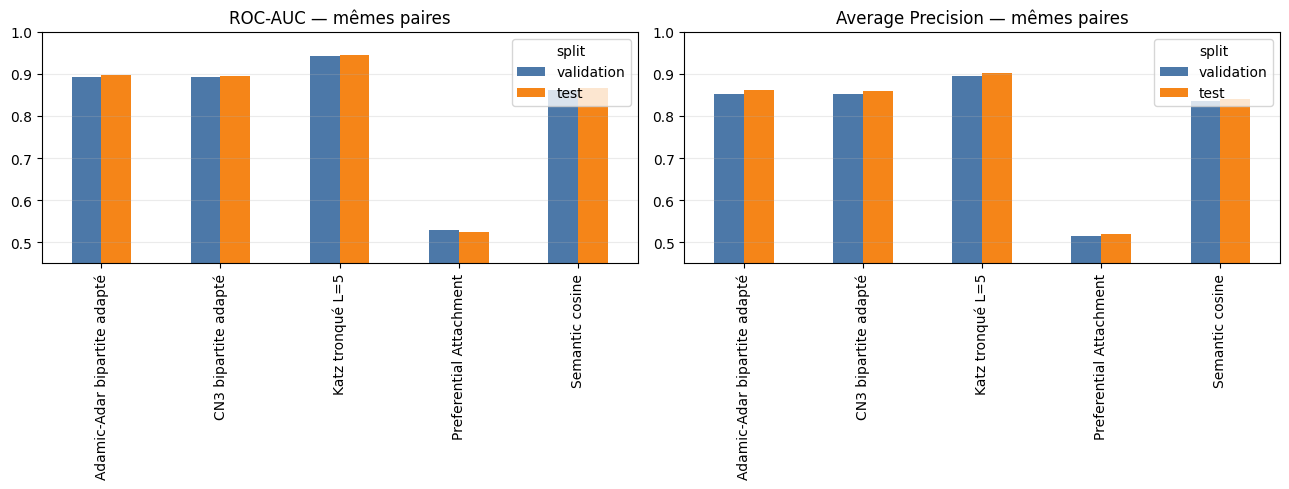

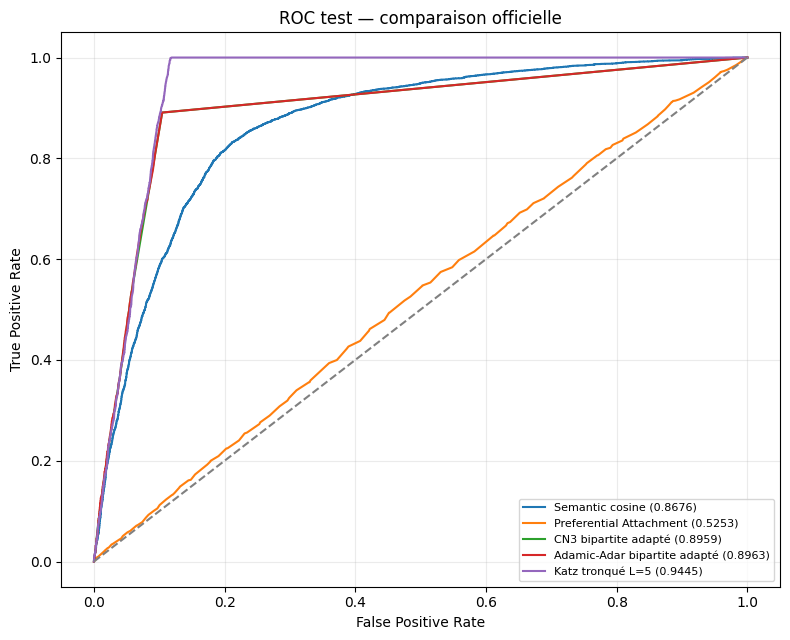

In [4]:
plot_data = comparison.pivot(index="method", columns="split", values=["roc_auc", "average_precision"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, ["roc_auc", "average_precision"], ["ROC-AUC", "Average Precision"]):
    plot_data[metric][["validation", "test"]].plot.bar(ax=ax, color=["#4C78A8", "#F58518"])
    ax.set_title(title + " — mêmes paires")
    ax.set_ylim(0.45, 1.0); ax.set_xlabel(""); ax.grid(axis="y", alpha=.25)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "method_comparison_auc_ap.png", dpi=170, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6.5))
for method, column in score_columns.items():
    fpr, tpr, _ = roc_curve(test_scores["label"], test_scores[column])
    auc = roc_auc_score(test_scores["label"], test_scores[column])
    ax.plot(fpr, tpr, label=f"{method} ({auc:.4f})")
ax.plot([0,1], [0,1], "--", color="gray"); ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC test — comparaison officielle")
ax.legend(fontsize=8); ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_comparison_test.png", dpi=170, bbox_inches="tight"); plt.show()

## 4. Complémentarité sémantique–structure

La corrélation de Spearman compare l'ordre des scores, sans supposer une relation linéaire. Une
corrélation faible ou modérée indique que texte et topologie ordonnent différemment les paires.
Avec les seuils déjà gelés, nous distinguons les décisions correctes par les deux méthodes, par une
seule, ou par aucune. Cette analyse test est descriptive : elle ne déclenche aucun réglage.

Corrélations : {'validation': {'spearman_rho': 0.62808536767108, 'pvalue': 0.0}, 'test': {'spearman_rho': 0.6356324686617917, 'pvalue': 0.0}}
Chevauchement des décisions test : {'correct_by_both': 11954, 'correct_only_semantic': 174, 'correct_only_structural': 2158, 'incorrect_by_both': 714}


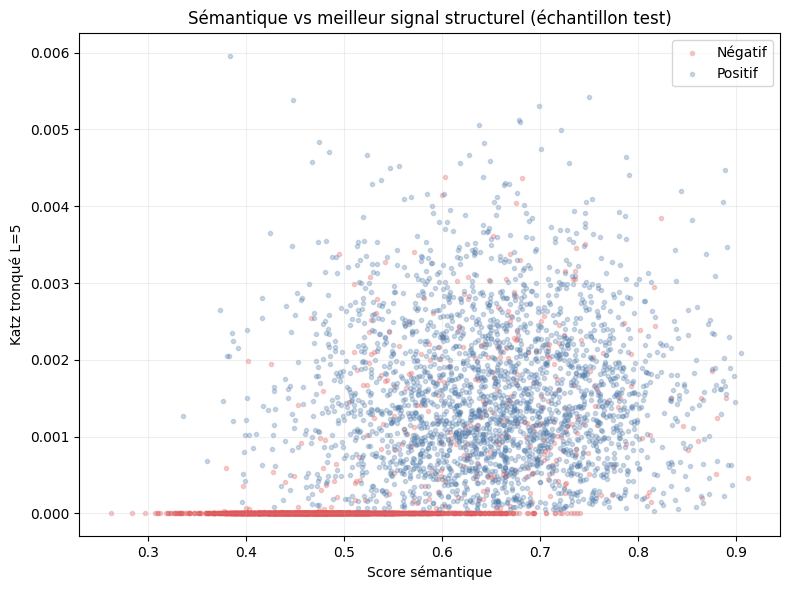

In [5]:
correlations = {}
for name, frame in [("validation", val_scores), ("test", test_scores)]:
    rho, pvalue = spearmanr(frame["semantic_score"], frame[best_structural_column])
    correlations[name] = {"spearman_rho": float(rho), "pvalue": float(pvalue)}

y_test = test_scores["label"].to_numpy()
sem_correct = (test_scores["semantic_score"].to_numpy() >= thresholds["Semantic cosine"]) == y_test
str_correct = (test_scores[best_structural_column].to_numpy() >= thresholds[best_structural_method]) == y_test
error_overlap = {
    "correct_by_both": int((sem_correct & str_correct).sum()),
    "correct_only_semantic": int((sem_correct & ~str_correct).sum()),
    "correct_only_structural": int((~sem_correct & str_correct).sum()),
    "incorrect_by_both": int((~sem_correct & ~str_correct).sum()),
}
print("Corrélations :", correlations)
print("Chevauchement des décisions test :", error_overlap)

rng = np.random.default_rng(SEED)
sample = test_scores.iloc[rng.choice(len(test_scores), min(5000, len(test_scores)), replace=False)]
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "#E15759", "Négatif"), (1, "#4C78A8", "Positif")]:
    part = sample[sample.label == label]
    ax.scatter(part.semantic_score, part[best_structural_column], s=9, alpha=.28, color=color, label=name)
ax.set(xlabel="Score sémantique", ylabel=best_structural_method, title="Sémantique vs meilleur signal structurel (échantillon test)")
ax.legend(); ax.grid(alpha=.2); fig.tight_layout()
fig.savefig(FIGURES_DIR / "semantic_vs_structural_scores.png", dpi=170, bbox_inches="tight"); plt.show()

## 5. Pourquoi un ranking réaliste est nécessaire

Un seuil F1 appris sur un benchmark 50/50 ne peut pas être appliqué aveuglément à environ 25
millions de paires dont seulement 0,3 % sont positives : même un faible taux de faux positifs peut
produire énormément d'arêtes. C'est le **problème du base-rate**.

Nous classons donc les candidats séparément pour chaque Job. Pour validation, les candidats sont
ses positifs validation et tous les vrais non-liens de `G_full`; train et test positifs sont exclus.
Pour test, les positifs test remplacent ceux de validation. `G_train` demeure la seule topologie
autorisée pour Katz, tandis que `G_full` sert uniquement de blacklist/vérité terrain.

Pour un Job, $Precision@K=\frac{\text{positifs dans le top K}}{K}$ et
$Recall@K=\frac{\text{positifs retrouvés dans le top K}}{\text{positifs cachés}}$. HitRate@K vaut 1
si au moins un positif est retrouvé. Les moyennes macro portent sur les Jobs possédant au moins un
positif dans le split; les autres n'ont pas de recall défini.

In [6]:
with (DATA_DIR / "cv_job_graph_link_train.pkl").open("rb") as f: G_train = pickle.load(f)
with (DATA_DIR / "cv_job_graph.pkl").open("rb") as f: G_full = pickle.load(f)
resume_embeddings = np.load(DATA_DIR / "resume_embeddings.npy")
job_embeddings = np.load(DATA_DIR / "job_embeddings.npy")
resume_ids = pd.read_csv(DATA_DIR / "resume_embedding_ids.csv")["resume_id"].astype(str).tolist()
job_ids = pd.read_csv(DATA_DIR / "job_embedding_ids.csv")["job_id"].astype(str).tolist()
resume_to_row = {node: i for i, node in enumerate(resume_ids)}
job_to_col = {node: j for j, node in enumerate(job_ids)}
assert G_train.number_of_edges() == 60_000 and G_full.number_of_edges() == 75_000
assert np.allclose(np.linalg.norm(resume_embeddings, axis=1), 1, atol=1e-4)
assert np.allclose(np.linalg.norm(job_embeddings, axis=1), 1, atol=1e-4)
print("Graphes et embeddings chargés.")

Graphes et embeddings chargés.


## 6. Matrice bipartite et Katz tronqué de l'évaluation

La matrice sparse $B$ vaut 1 pour une arête de `G_train`. Comme à l'Étape 8,
$W_3=B(B^TB)$ et $W_5=W_3(B^TB)$ comptent les marches de longueur 3 et 5, puis
$Katz_5=\beta^3W_3+\beta^5W_5$. Aucun tableau dense 10 000×2 500 n'est conservé.

Nous récupérons le $\beta$ choisi antérieurement sur validation. Pour chaque Job, seule sa colonne
sparse est convertie en un vecteur de 10 000 scores, taille raisonnable.

In [7]:
def bipartite_matrix(graph):
    rows, cols = [], []
    for r, j in graph.edges():
        if graph.nodes[r].get("node_type") == "Job": r, j = j, r
        rows.append(resume_to_row[r]); cols.append(job_to_col[j])
    return sparse.csr_matrix((np.ones(len(rows), dtype=np.float64), (rows, cols)),
                             shape=(len(resume_ids), len(job_ids)))

def sparse_column(matrix, col):
    return np.asarray(matrix.getcol(col).toarray()).ravel()

B_train = bipartite_matrix(G_train)
P_train = (B_train.T @ B_train).tocsr()
W3_train = (B_train @ P_train).tocsr()
W5_train = (W3_train @ P_train).tocsr()
selected_beta = float(classical_summary["selected_beta"])
Katz_train = (selected_beta**3 * W3_train + selected_beta**5 * W5_train).tocsr()
lambda_train = float(classical_summary["lambda_max"])
beta_fraction = float(selected_beta * lambda_train)
print("beta train / fraction conservée :", selected_beta, beta_fraction)

beta train / fraction conservée : 0.06457108750434394 0.9


## 7. Classements par Job, sans matrice dense globale

Les cosinus sont calculés par lots de Jobs grâce au produit scalaire des embeddings normalisés.
Un masque écarte les matches connus de `G_full`, puis réautorise uniquement les positifs du split
courant. Les égalités sont départagées de manière déterministe par l'ordre du mapping CV.

Le consensus est l'intersection `SemanticTopK ∩ KatzTopK`. Il est conservateur : une paire doit être
très bien classée par le texte **et** la structure. Comme l'intersection peut contenir moins de K
éléments, ses métriques sont nommées `consensus_precision/recall/F1`, pas Precision@K.

In [8]:
K_VALUES = [1, 3, 5, 10, 20, 50]
MAX_K = max(K_VALUES)
all_rows = np.arange(len(resume_ids))
full_neighbor_rows = {j: np.array([resume_to_row[r] for r in G_full.neighbors(j)], dtype=int) for j in job_ids}

def positives_by_job(frame):
    pos = frame[frame.label == 1].groupby("job_id")["resume_id"].apply(list).to_dict()
    return {j: {resume_to_row[r] for r in rs} for j, rs in pos.items()}

def top_rows(scores, allowed, k, positive_only=False):
    candidates = all_rows[allowed]
    if positive_only:
        candidates = candidates[scores[candidates] > 0]
    if len(candidates) == 0: return np.array([], dtype=int)
    order = np.lexsort((candidates, -scores[candidates]))
    return candidates[order[:k]]

def build_rankings(target_frame, batch_size=100):
    relevant = positives_by_job(target_frame)
    sem_top, katz_top = {}, {}
    for start in range(0, len(job_ids), batch_size):
        cols = np.arange(start, min(start + batch_size, len(job_ids)))
        semantic_batch = resume_embeddings @ job_embeddings[cols].T
        for local, col in enumerate(cols):
            job = job_ids[col]
            if job not in relevant: continue
            allowed = np.ones(len(resume_ids), dtype=bool)
            allowed[full_neighbor_rows[job]] = False
            allowed[list(relevant[job])] = True
            sem = semantic_batch[:, local]
            katz = sparse_column(Katz_train, col)
            sem_top[job] = top_rows(sem, allowed, MAX_K)
            katz_top[job] = top_rows(katz, allowed, MAX_K)
    return relevant, sem_top, katz_top

ranking_start = time.perf_counter()
val_relevant, val_sem_top, val_katz_top = build_rankings(split_val)
test_relevant, test_sem_top, test_katz_top = build_rankings(split_test)
print("Jobs évaluables validation/test :", len(val_relevant), len(test_relevant))
print("Temps de construction des classements :", round(time.perf_counter()-ranking_start, 2), "s")

Jobs évaluables validation/test : 2390 2403
Temps de construction des classements : 43.64 s


## 8. Métriques de ranking et sélection de K sur validation

Les métriques sémantique et Katz sont des moyennes macro par Job avec positif caché. Le consensus
est agrégé sur ces Jobs : sa couverture est leur proportion ayant une intersection non vide.

Nous choisissons K **uniquement sur validation** : F1 consensus maximal, puis précision maximale,
puis plus petit K. Le test reste intact jusqu'au gel de K.

In [9]:
def macro_topk(relevant, tops, k):
    rows = []
    for job, positives in relevant.items():
        chosen = set(tops[job][:k])
        hits = len(chosen & positives)
        rows.append((hits/k, hits/len(positives), float(hits > 0)))
    a = np.asarray(rows)
    return {"precision_at_k": float(a[:,0].mean()), "recall_at_k": float(a[:,1].mean()),
            "hit_rate_at_k": float(a[:,2].mean()), "n_jobs_evaluated": len(rows)}

def consensus_metrics(relevant, sem_top, katz_top, k):
    predicted = hits = covered = total_relevant = 0
    for job, positives in relevant.items():
        consensus = set(sem_top[job][:k]) & set(katz_top[job][:k])
        predicted += len(consensus); hits += len(consensus & positives)
        total_relevant += len(positives); covered += bool(consensus)
    precision = hits/predicted if predicted else 0.0
    recall = hits/total_relevant if total_relevant else 0.0
    f1 = 2*precision*recall/(precision+recall) if precision+recall else 0.0
    return {"n_predictions": predicted, "n_hits": hits, "consensus_precision": precision,
            "consensus_recall": recall, "consensus_f1": f1,
            "coverage": covered/len(relevant), "n_jobs_evaluated": len(relevant)}

validation_ranking_rows = []
consensus_val_by_k = {}
for k in K_VALUES:
    for method, tops in [("Semantic cosine", val_sem_top), ("Katz tronqué L=5", val_katz_top)]:
        validation_ranking_rows.append({"method": method, "k": k, **macro_topk(val_relevant, tops, k)})
    consensus_val_by_k[k] = consensus_metrics(val_relevant, val_sem_top, val_katz_top, k)
    validation_ranking_rows.append({"method": "Consensus Semantic∩Katz", "k": k, **consensus_val_by_k[k]})
ranking_validation = pd.DataFrame(validation_ranking_rows)
ranking_validation.to_csv(RESULTS_DIR / "step9_ranking_validation.csv", index=False)

selected_consensus_k = sorted(K_VALUES, key=lambda k: (-consensus_val_by_k[k]["consensus_f1"],
                                                        -consensus_val_by_k[k]["consensus_precision"], k))[0]
print("K retenu uniquement sur validation :", selected_consensus_k)
display(ranking_validation.round(6))

K retenu uniquement sur validation : 50


,method,k,precision_at_k,recall_at_k,hit_rate_at_k,n_jobs_evaluated,n_predictions,n_hits,consensus_precision,consensus_recall,consensus_f1,coverage
0,Semantic cosine,1,0.003766,0.000950,0.003766,2390,NaN,NaN,NaN,NaN,NaN,NaN
1,Katz tronqué L=5,1,0.003766,0.001092,0.003766,2390,NaN,NaN,NaN,NaN,NaN,NaN
2,Consensus Semantic∩Katz,1,NaN,NaN,NaN,2390,4.0,0.0,0.000000,0.000000,0.000000,0.001674
3,Semantic cosine,3,0.004184,0.003655,0.012134,2390,NaN,NaN,NaN,NaN,NaN,NaN
4,Katz tronqué L=5,3,0.003347,0.003192,0.010042,2390,NaN,NaN,NaN,NaN,NaN,NaN
5,Consensus Semantic∩Katz,3,NaN,NaN,NaN,2390,21.0,1.0,0.047619,0.000133,0.000266,0.008787
6,Semantic cosine,5,0.003849,0.005916,0.018828,2390,NaN,NaN,NaN,NaN,NaN,NaN
7,Katz tronqué L=5,5,0.003096,0.005089,0.015481,2390,NaN,NaN,NaN,NaN,NaN,NaN
8,Consensus Semantic∩Katz,5,NaN,NaN,NaN,2390,62.0,1.0,0.016129,0.000133,0.000264,0.025523
9,Semantic cosine,10,0.003013,0.009312,0.029707,2390,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Évaluation finale du ranking sur test

K est maintenant gelé. Nous calculons une seule fois les métriques test de Semantic, Katz et du
consensus. Aucun résultat test ne modifiera K, $\beta$, les embeddings ou la règle d'intersection.

,method,k,precision_at_k,recall_at_k,hit_rate_at_k,n_jobs_evaluated,n_predictions,n_hits,consensus_precision,consensus_recall,consensus_f1,coverage
0,Semantic cosine,50,0.002838,0.043626,0.134415,2403,NaN,NaN,NaN,NaN,NaN,NaN
1,Katz tronqué L=5,50,0.003254,0.049923,0.148980,2403,NaN,NaN,NaN,NaN,NaN,NaN
2,Consensus Semantic∩Katz,50,NaN,NaN,NaN,2403,5024.0,18.0,0.003583,0.0024,0.002874,0.88764


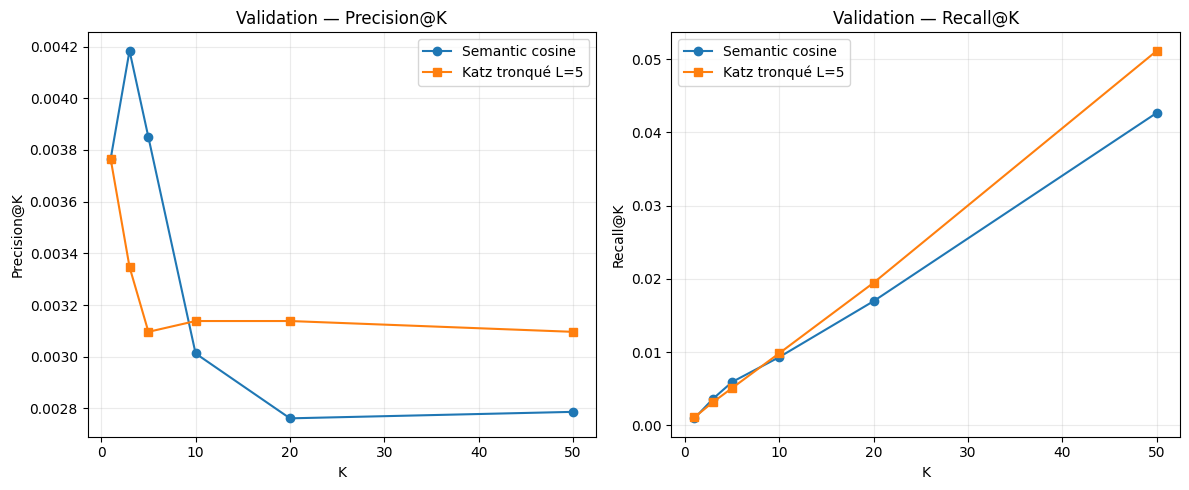

In [10]:
test_semantic_metrics = macro_topk(test_relevant, test_sem_top, selected_consensus_k)
test_katz_metrics = macro_topk(test_relevant, test_katz_top, selected_consensus_k)
test_consensus_metrics = consensus_metrics(test_relevant, test_sem_top, test_katz_top, selected_consensus_k)
ranking_test = pd.DataFrame([
    {"method": "Semantic cosine", "k": selected_consensus_k, **test_semantic_metrics},
    {"method": "Katz tronqué L=5", "k": selected_consensus_k, **test_katz_metrics},
    {"method": "Consensus Semantic∩Katz", "k": selected_consensus_k, **test_consensus_metrics},
])
ranking_test.to_csv(RESULTS_DIR / "step9_ranking_test.csv", index=False)
display(ranking_test.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for method, marker in [("Semantic cosine", "o"), ("Katz tronqué L=5", "s")]:
    part = ranking_validation[ranking_validation.method == method]
    axes[0].plot(part.k, part.precision_at_k, marker=marker, label=method)
    axes[1].plot(part.k, part.recall_at_k, marker=marker, label=method)
axes[0].set(title="Validation — Precision@K", xlabel="K", ylabel="Precision@K")
axes[1].set(title="Validation — Recall@K", xlabel="K", ylabel="Recall@K")
for ax in axes: ax.grid(alpha=.25); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES_DIR / "ranking_precision_recall.png", dpi=170, bbox_inches="tight"); plt.show()

## 10. Passage de l'évaluation au déploiement

Jusqu'ici, `G_train` (60 000 arêtes) était indispensable pour cacher sans fuite les 15 000 liens de
validation/test. La méthode, $\beta$ et K sont maintenant fixés. En déploiement, le réseau observé
contient les 75 000 correspondances connues : le graphe enrichi doit donc repartir de `G_full`, et
non de `G_train`.

Nous recalculons Katz sur `G_full`. Nous ne retunons pas $\beta$ : nous conservons la fraction
$f=\beta_{train}\lambda_{train}$ et posons $\beta_{full}=f/\lambda_{full}$. Les embeddings ne
changent pas. Une nouvelle candidate doit être absente de `G_full`, appartenir aux deux Top-K et
avoir un score Katz strictement positif.

In [11]:
B_full = bipartite_matrix(G_full)
P_full = (B_full.T @ B_full).tocsr()
largest_eigenvalue_full = float(eigsh(P_full, k=1, which="LM", v0=np.ones(P_full.shape[0]),
                                      return_eigenvectors=False)[0])
lambda_max_full = float(np.sqrt(max(largest_eigenvalue_full, 0.0)))
beta_full = float(beta_fraction / lambda_max_full)
W3_full = (B_full @ P_full).tocsr()
W5_full = (W3_full @ P_full).tocsr()
Katz_full = (beta_full**3 * W3_full + beta_full**5 * W5_full).tocsr()
assert beta_full < 1/lambda_max_full
print("lambda_full / beta_full :", lambda_max_full, beta_full)

lambda_full / beta_full : 17.146427876815295 0.05248906690453838


## 11. Nouveaux candidats par consensus

Pour chaque Job, nous classons uniquement les CV sans arête dans `G_full`. Le rang est propre à
chaque méthode et commence à 1. L'intersection conserve les scores et les rangs qui justifient
l'ajout. Aucun seuil global supplémentaire n'est introduit après observation du test.

In [12]:
enrichment_rows = []
for start in range(0, len(job_ids), 100):
    cols = np.arange(start, min(start + 100, len(job_ids)))
    semantic_batch = resume_embeddings @ job_embeddings[cols].T
    for local, col in enumerate(cols):
        job = job_ids[col]
        allowed = np.ones(len(resume_ids), dtype=bool)
        allowed[full_neighbor_rows[job]] = False
        semantic_scores = semantic_batch[:, local]
        katz_scores = sparse_column(Katz_full, col)
        sem_rows = top_rows(semantic_scores, allowed, selected_consensus_k)
        katz_rows = top_rows(katz_scores, allowed, selected_consensus_k, positive_only=True)
        sem_rank = {row: rank for rank, row in enumerate(sem_rows, 1)}
        katz_rank = {row: rank for rank, row in enumerate(katz_rows, 1)}
        for row in sorted(set(sem_rows) & set(katz_rows)):
            enrichment_rows.append({
                "resume_id": resume_ids[row], "job_id": job,
                "semantic_score": float(semantic_scores[row]), "semantic_rank": sem_rank[row],
                "katz_score": float(katz_scores[row]), "katz_rank": katz_rank[row],
                "selected_k": int(selected_consensus_k),
                "prediction_method": "semantic_katz_consensus",
            })
enrichment_candidates = pd.DataFrame(enrichment_rows)
if enrichment_candidates.empty:
    enrichment_candidates = pd.DataFrame(columns=["resume_id","job_id","semantic_score","semantic_rank",
        "katz_score","katz_rank","selected_k","prediction_method"])
enrichment_candidates.to_csv(RESULTS_DIR / "step9_enrichment_candidates.csv", index=False)
print("Nouvelles arêtes consensus :", len(enrichment_candidates))
display(enrichment_candidates.head(10))

Nouvelles arêtes consensus : 5347


,resume_id,job_id,semantic_score,semantic_rank,katz_score,katz_rank,selected_k,prediction_method
0,R_003561,J_000000,0.797737,31,0.003779,23,50,semantic_katz_consensus
1,R_006124,J_000000,0.796500,33,0.003752,25,50,semantic_katz_consensus
2,R_000084,J_000001,0.865534,6,0.003307,22,50,semantic_katz_consensus
3,R_002125,J_000001,0.815022,38,0.003431,14,50,semantic_katz_consensus
4,R_002746,J_000001,0.844096,22,0.002968,49,50,semantic_katz_consensus
5,R_003831,J_000001,0.805173,47,0.003694,7,50,semantic_katz_consensus
6,R_005014,J_000001,0.805288,46,0.003182,28,50,semantic_katz_consensus
7,R_008311,J_000001,0.851533,16,0.003423,15,50,semantic_katz_consensus
8,R_008358,J_000001,0.858228,10,0.003455,12,50,semantic_katz_consensus
9,R_004892,J_000002,0.866680,39,0.003362,40,50,semantic_katz_consensus


## 12. Construction sûre du graphe enrichi

Une copie indépendante de `G_full` est créée. Les arêtes historiques reçoivent `edge_type=observed`
sans perdre leurs attributs. Chaque arête ajoutée conserve la méthode, les deux scores, K et l'étape
d'origine : ces métadonnées évitent de confondre vérité observée et prédiction dans les analyses
futures. Le fichier original n'est jamais écrasé.

In [13]:
G_enriched = G_full.copy()
for _, _, data in G_enriched.edges(data=True):
    data.setdefault("edge_type", "observed")
for row in enrichment_candidates.itertuples(index=False):
    G_enriched.add_edge(row.resume_id, row.job_id, edge_type="predicted",
                        prediction_method=row.prediction_method,
                        semantic_score=float(row.semantic_score), katz_score=float(row.katz_score),
                        selected_k=int(row.selected_k), source_step=9)
with (DATA_DIR / "cv_job_graph_enriched.pkl").open("wb") as f:
    pickle.dump(G_enriched, f, protocol=pickle.HIGHEST_PROTOCOL)
print("Graphe enrichi sauvegardé.")

Graphe enrichi sauvegardé.


## 13. Effet structurel limité de l'enrichissement

Nous mesurons seulement les changements demandés : arêtes, densité bipartite, degrés moyens,
composantes et isolés. Il ne s'agit pas d'une répétition de l'analyse structurelle, et les
communautés ne sont pas recalculées.

,n_edges,bipartite_density,average_degree_cv,average_degree_job,n_connected_components,n_isolates
before,75000.0,0.003000,7.5000,30.0000,36.0,29.0
after,80347.0,0.003214,8.0347,32.1388,36.0,29.0


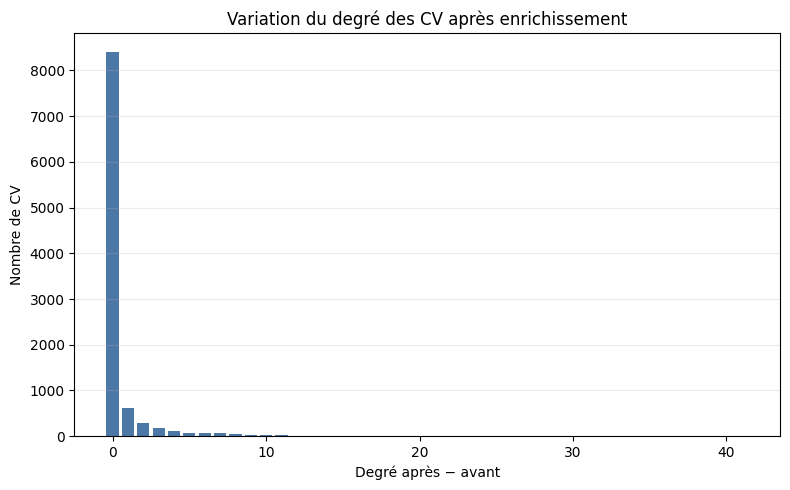

In [14]:
cv_ids = [n for n,d in G_full.nodes(data=True) if d.get("node_type") == "CV"]
graph_stats = {}
for name, graph in [("before", G_full), ("after", G_enriched)]:
    graph_stats[name] = {
        "n_edges": int(graph.number_of_edges()),
        "bipartite_density": float(graph.number_of_edges()/(len(resume_ids)*len(job_ids))),
        "average_degree_cv": float(np.mean([graph.degree(n) for n in resume_ids])),
        "average_degree_job": float(np.mean([graph.degree(n) for n in job_ids])),
        "n_connected_components": int(nx.number_connected_components(graph)),
        "n_isolates": int(nx.number_of_isolates(graph)),
    }
display(pd.DataFrame(graph_stats).T)

before_cv = np.array([G_full.degree(n) for n in resume_ids])
after_cv = np.array([G_enriched.degree(n) for n in resume_ids])
fig, ax = plt.subplots(figsize=(8, 5))
values, counts = np.unique(after_cv-before_cv, return_counts=True)
ax.bar(values, counts, color="#4C78A8"); ax.set(title="Variation du degré des CV après enrichissement", xlabel="Degré après − avant", ylabel="Nombre de CV")
ax.grid(axis="y", alpha=.25); fig.tight_layout()
fig.savefig(FIGURES_DIR / "enrichment_degree_change.png", dpi=170, bbox_inches="tight"); plt.show()

## 14. Assertions anti-fuite et intégrité

Ces assertions matérialisent les frontières expérimentales : mêmes splits, K issu de validation,
Katz d'évaluation construit sur `G_train`, enrichissement construit sur `G_full`, absence de
doublons et métadonnées complètes. Un échec interrompt le notebook au lieu de produire un résultat
silencieusement invalide.

In [15]:
assert selected_consensus_k in K_VALUES
best_check = sorted(K_VALUES, key=lambda k: (-consensus_val_by_k[k]["consensus_f1"],
                                              -consensus_val_by_k[k]["consensus_precision"], k))[0]
assert selected_consensus_k == best_check
assert B_train.nnz == 60_000 and B_full.nnz == 75_000
assert len(enrichment_candidates) == len(enrichment_candidates.drop_duplicates(["resume_id","job_id"]))
assert all(not G_full.has_edge(r,j) for r,j in enrichment_candidates[["resume_id","job_id"]].itertuples(index=False, name=None))
assert all(G_full.nodes[r].get("node_type") == "CV" and G_full.nodes[j].get("node_type") == "Job"
           for r,j in enrichment_candidates[["resume_id","job_id"]].itertuples(index=False, name=None))
assert (enrichment_candidates["katz_score"] > 0).all() if len(enrichment_candidates) else True
assert G_full.number_of_edges() == 75_000
assert G_enriched.number_of_edges() == 75_000 + len(enrichment_candidates)
for row in enrichment_candidates.itertuples(index=False):
    data = G_enriched.edges[row.resume_id, row.job_id]
    assert all(key in data for key in ["edge_type","prediction_method","semantic_score","katz_score","selected_k","source_step"])
assert all(not G_train.has_edge(r,j) for r,j in split_val[["resume_id","job_id"]].itertuples(index=False, name=None))
assert all(not G_train.has_edge(r,j) for r,j in split_test[["resume_id","job_id"]].itertuples(index=False, name=None))
print("Toutes les assertions anti-fuite et d'intégrité sont passées.")

Toutes les assertions anti-fuite et d'intégrité sont passées.


## 15. Résumé reproductible

Le JSON rassemble les résultats du benchmark, le choix structurel effectué sur validation, la
complémentarité, tous les rankings, le transfert de $\beta$ et les changements du graphe. Il rend
explicite l'absence d'optimisation test et de classification.

In [16]:
def records_by_k(rows, method):
    return {str(int(r["k"])): {k: (int(v) if k in ["k","n_jobs_evaluated","n_predictions","n_hits"] and pd.notna(v) else float(v))
                               for k,v in r.items() if k not in ["method","k"] and pd.notna(v)}
            for r in rows[rows.method == method].to_dict(orient="records")}

summary = {
    "balanced_benchmark_results": comparison.to_dict(orient="records"),
    "best_validation_structural_method": best_structural_method,
    "semantic_vs_structural_spearman": correlations,
    "error_overlap_statistics": error_overlap,
    "ranking_k_values": K_VALUES,
    "ranking_jobs_with_positives": {"validation": len(val_relevant), "test": len(test_relevant)},
    "semantic_validation_ranking_metrics": records_by_k(ranking_validation, "Semantic cosine"),
    "katz_validation_ranking_metrics": records_by_k(ranking_validation, "Katz tronqué L=5"),
    "consensus_validation_metrics": {str(k): v for k,v in consensus_val_by_k.items()},
    "selected_consensus_k": int(selected_consensus_k),
    "selection_rule": "max validation consensus F1, then max precision, then smallest K",
    "semantic_test_ranking_metrics": test_semantic_metrics,
    "katz_test_ranking_metrics": test_katz_metrics,
    "consensus_test_metrics": test_consensus_metrics,
    "beta_fraction": beta_fraction,
    "lambda_max_full": lambda_max_full,
    "beta_full": beta_full,
    "n_observed_edges_before": 75_000,
    "n_predicted_edges_added": int(len(enrichment_candidates)),
    "n_edges_after": int(G_enriched.number_of_edges()),
    "density_before_after": {x: graph_stats[x]["bipartite_density"] for x in graph_stats},
    "degree_statistics_before_after": {x: {k:v for k,v in graph_stats[x].items() if "degree" in k} for x in graph_stats},
    "n_components_before_after": {x: graph_stats[x]["n_connected_components"] for x in graph_stats},
    "n_isolates_before_after": {x: graph_stats[x]["n_isolates"] for x in graph_stats},
    "anti_leakage_confirmation": {
        "same_step6_pairs": True, "no_test_optimization": True,
        "validation_and_test_katz_topology": "G_train only",
        "G_full_during_evaluation": "ground-truth blacklist only",
        "enrichment_base": "G_full with 75000 observed edges",
    },
    "classification_started": False,
    "communities_recomputed": False,
    "runtime_seconds": float(time.perf_counter()-start_time),
    "all_assertions_passed": True,
}
(RESULTS_DIR / "step9_link_prediction_comparison_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print("Résumé sauvegardé. Temps total :", round(summary["runtime_seconds"], 2), "s")

Résumé sauvegardé. Temps total : 70.7 s


## Interprétation et conclusion

- Sur le benchmark équilibré, **Katz tronqué L=5 domine** : ROC-AUC validation/test
  `0,9419 / 0,9445`, contre `0,8623 / 0,8676` pour le cosinus sémantique. Katz est donc aussi la
  meilleure méthode structurelle choisie sur validation. Le cosinus reste utile car il exploite le
  texte, tandis que Katz exploite les marches de `G_train`.
- Leur corrélation de Spearman est **modérée** (`0,6281` validation, `0,6356` test), pas parfaite.
  Sur les 15 000 paires test, les deux décisions sont correctes pour `11 954` paires ; le sémantique
  seul en corrige `174`, Katz seul `2 158`, et les deux échouent sur `714`. Les signaux sont donc
  partiellement complémentaires, mais Katz contribue davantage au seuil choisi.
- Le ranking réaliste est beaucoup plus difficile que le benchmark 50/50. À `K=50`, la validation
  donne Precision@50 `0,00279` / Recall@50 `0,04266` pour Semantic et `0,00310` / `0,05113` pour
  Katz. Sur test : Semantic `0,00284 / 0,04363`, Katz `0,00325 / 0,04992`. Ces faibles précisions
  illustrent directement le base-rate naturel et empêchent d'interpréter la forte AUC comme une
  garantie de recommandations très précises parmi des milliers de CV.
- La règle imposée retient **K=50** sur validation, car il maximise le F1 du consensus parmi les K
  testés. Son F1 demeure très faible : validation, `4 994` prédictions, précision `0,00300`, recall
  `0,00200`, F1 `0,00240`, couverture `0,8879`; test, `5 024` prédictions, précision `0,00358`,
  recall `0,00240`, F1 `0,00287`, couverture `0,8876`. Le consensus améliore légèrement la précision
  test par rapport aux Top-50 individuels, au prix d'un recall extrêmement faible.
- En déploiement, la fraction de Katz `0,9` est transférée sans retuning :
  $\lambda_{full}=17,1464$ et $\beta_{full}=0,052489$. Le consensus ajoute `5 347` non-arêtes à une
  copie des `75 000` liens observés, soit `80 347` arêtes. La densité bipartite passe de `0,003000`
  à `0,00321388`; le degré moyen passe de `7,5` à `8,0347` pour les CV et de `30` à `32,1388` pour
  les Jobs. Les `36` composantes et `29` isolés restent inchangés.
- Cette règle est plus prudente qu'un seuil global parce qu'elle exige un haut rang local selon deux
  signaux et limite le nombre de recommandations par Job. Cependant, sa précision mesurée sur les
  liens cachés est faible : les `5 347` nouvelles arêtes doivent rester explicitement marquées
  **prédites**, pas assimilées à une vérité terrain.
- Enfin, le dataset synthétique peut faciliter certains signaux et ne reproduit pas un marché réel.
  Les non-liens proposés n'ont aucune vérité terrain future : leur pertinence réelle ne peut pas être
  prouvée ici. Aucune classification et aucun recalcul de communauté n'ont été commencés.